# PDE Solution

In [22]:
import torch
from torch import nn
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pinn.lib import SchrodingerData, SchrodingerModel, get_loss, Util

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [24]:
import os

os.makedirs("Data", exist_ok=True)

import requests

url = "https://github.com/maziarraissi/PINNs/raw/master/main/Data/NLS.mat"
r = requests.get(url)

with open("Data/NLS.mat", "wb") as f:
    f.write(r.content)

print("Downloaded NLS.mat to Data/NLS.mat")

Downloaded NLS.mat to Data/NLS.mat


In [25]:
data = scipy.io.loadmat('Data/NLS.mat')

t_np = data['tt'].flatten()[:,None]
x_np = data['x'].flatten()[:,None]
Exact = data['uu']
Exact_u = np.real(Exact)
Exact_v = np.imag(Exact)

In [26]:
t_np.shape, x_np.shape, Exact.shape

((201, 1), (256, 1), (256, 201))

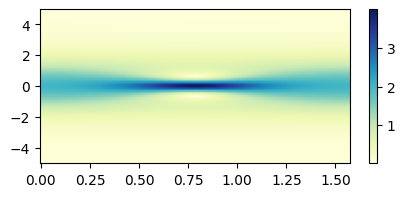

In [39]:
T_np, X_np = np.meshgrid(t_np.squeeze(), x_np.squeeze())

plt.figure(figsize=(5,2))
plt.pcolormesh(T_np, X_np, np.abs(Exact), cmap="YlGnBu")
plt.colorbar()
plt.show()

In [40]:
torch.cuda.manual_seed(42)
torch.manual_seed(42)

In [27]:
util = Util()
schrodinger_data = SchrodingerData(util,
                                   Exact,
                                   x_np,
                                   n_data=50,
                                   n_boundary=50,
                                   n_collocation=20000,
                                   t_bound=[0, torch.pi / 2],
                                   x_bound=[-5, 5]
                                  )

In [28]:
epochs = 1000
schrodinger_model = SchrodingerModel(n_input=2,n_layer=3, n_out=2,                                   t_bound=[0, torch.pi / 2],
                                   x_bound=[-5, 5])
optimizer = torch.optim.Adam(schrodinger_model.parameters())
schrodinger_model.to(device)

SchrodingerModel(
  (first): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): Tanh()
  )
  (hidden): Sequential(
    (0): Sequential(
      (0): Linear(in_features=100, out_features=100, bias=True)
      (1): Tanh()
    )
    (1): Sequential(
      (0): Linear(in_features=100, out_features=100, bias=True)
      (1): Tanh()
    )
    (2): Sequential(
      (0): Linear(in_features=100, out_features=100, bias=True)
      (1): Tanh()
    )
  )
  (last): Linear(in_features=100, out_features=2, bias=True)
)

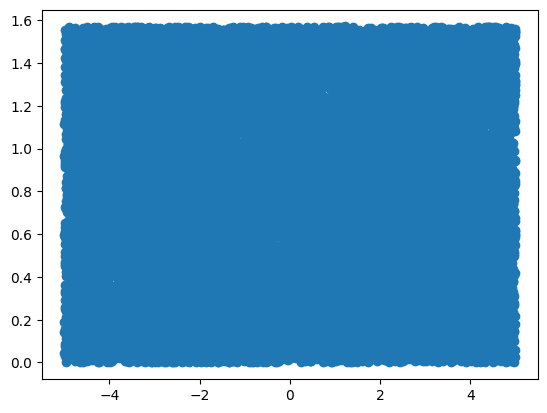

In [58]:
plt.scatter(schrodinger_data.x_collocation_points, schrodinger_data.t_collocation_points)

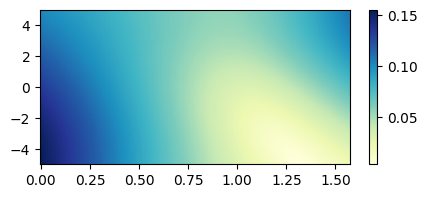

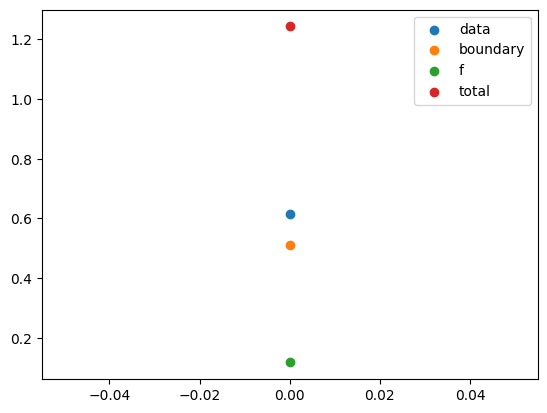

KeyboardInterrupt: 

In [29]:
data_losses = []
boundary_losses = []
f_losses = []
for i in range(epochs):
    optimizer.zero_grad()

    data_loss, boundary_loss, f_loss = get_loss(schrodinger_model, schrodinger_data)
    loss = data_loss + boundary_loss + f_loss

    loss.backward()

    optimizer.step()

    data_losses.append(data_loss.item())
    boundary_losses.append(boundary_loss.item())
    f_losses.append(f_loss.item())

    if i % (epochs // 10) == 0:
        T_np, X_np = np.meshgrid(t_np.flatten(), x_np.flatten())
        pairs = torch.tensor(np.column_stack([X_np.ravel(), T_np.ravel()]), device=device, dtype=torch.float)

        result = schrodinger_model(torch.tensor(X_np.ravel(), dtype=torch.float), torch.tensor(T_np.ravel(), dtype=torch.float))

        np_result = np.abs(result.detach().cpu().numpy()[:,1] * 1j + result.detach().cpu().numpy()[:,0])

        plt.figure(figsize=(5,2))
        plt.pcolormesh(T_np, X_np, np_result.reshape(x_np.shape[0], t_np.shape[0]), cmap="YlGnBu")
        plt.colorbar()
        plt.show()
        plt.scatter(np.arange(len(data_losses)), np.array(data_losses), label="data")
        plt.scatter(np.arange(len(boundary_losses)), np.array(boundary_losses), label="boundary")
        plt.scatter(np.arange(len(f_losses)), np.array(f_losses), label="f")
        plt.scatter(np.arange(len(boundary_losses)), np.array(boundary_losses) + np.array(data_losses) + np.array(f_losses), label="total")
        plt.legend()
        plt.show()





In [ ]:
import torch
from google.colab import drive
drive.mount('/content/drive')  # mounts your Drive

# Suppose your model is called 'model' and optimizer 'optimizer'
checkpoint_path = "/content/drive/MyDrive/schrodinger_model.pt"

torch.save({
    'model_state_dict': schrodinger_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': 15000,                # optional: last completed epoch
    'loss': (data_losses, boundary_losses, f_losses)                   # optional: last loss
}, checkpoint_path)

print(f"Checkpoint saved to {checkpoint_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint saved to /content/drive/MyDrive/schrodinger_model.pt


In [33]:
epochs = 1

checkpoint_path = "4Refactor/schrodinger_model-50000.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

schrodinger_model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

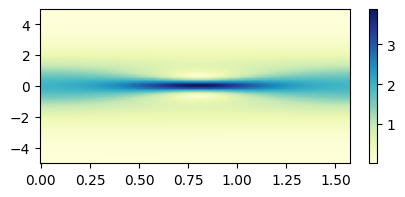

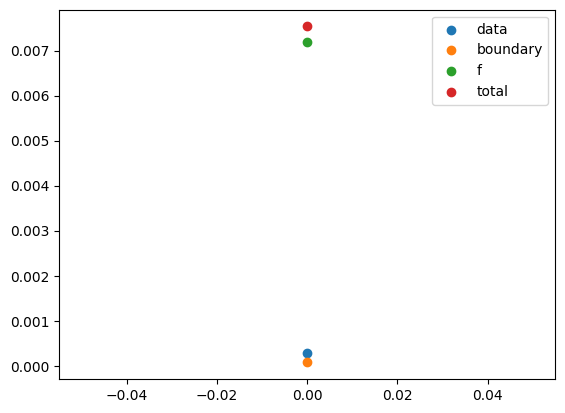

In [34]:
data_losses = []
boundary_losses = []
f_losses = []
for i in range(epochs):
    optimizer.zero_grad()

    data_loss, boundary_loss, f_loss = get_loss(schrodinger_model, schrodinger_data)
    loss = data_loss + boundary_loss + f_loss

    loss.backward()

    optimizer.step()

    data_losses.append(data_loss.item())
    boundary_losses.append(boundary_loss.item())
    f_losses.append(f_loss.item())

    if i % (epochs) == 0:
        T_np, X_np = np.meshgrid(t_np.flatten(), x_np.flatten())
        pairs = torch.tensor(np.column_stack([X_np.ravel(), T_np.ravel()]), dtype=torch.float, device=device)

        result = schrodinger_model(torch.tensor(X_np.ravel(), dtype=torch.float), torch.tensor(T_np.ravel(), dtype=torch.float))

        np_result = np.abs(result.detach().cpu().numpy()[:,1] * 1j + result.detach().cpu().numpy()[:,0])

        plt.figure(figsize=(5,2))
        plt.pcolormesh(T_np, X_np, np_result.reshape(x_np.shape[0], t_np.shape[0]), cmap="YlGnBu")
        plt.colorbar()
        plt.show()
        plt.scatter(np.arange(len(data_losses)), np.array(data_losses), label="data")
        plt.scatter(np.arange(len(boundary_losses)), np.array(boundary_losses), label="boundary")
        plt.scatter(np.arange(len(f_losses)), np.array(f_losses), label="f")
        plt.scatter(np.arange(len(boundary_losses)), np.array(boundary_losses) + np.array(data_losses) + np.array(f_losses), label="total")
        plt.legend()
        plt.show()


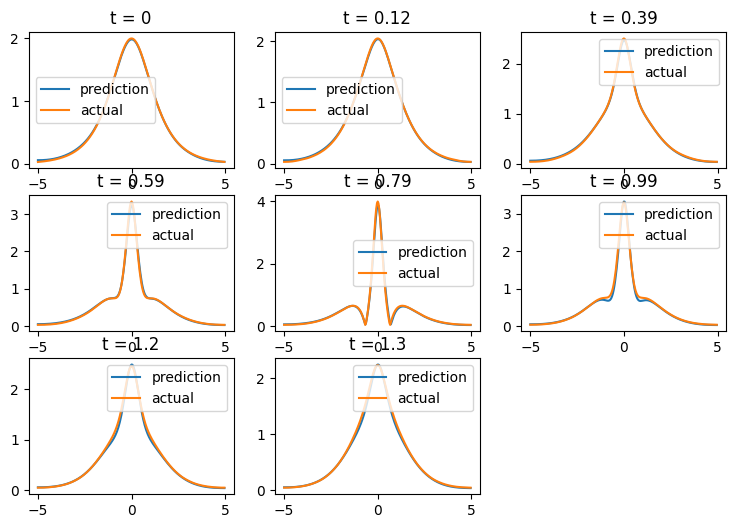

In [ ]:
plt.figure(figsize=(9,6))
T_np, X_np = np.meshgrid(t_np.flatten(), x_np.flatten())
pairs = torch.tensor(np.column_stack([X_np.ravel(), T_np.ravel()]), dtype=torch.float, device=device)

result = schrodinger_model(torch.tensor(X_np.ravel(), dtype=torch.float), torch.tensor(T_np.ravel(), dtype=torch.float))

np_result = np.abs(result.detach().cpu().numpy()[:,1] * 1j + result.detach().cpu().numpy()[:,0])
for idx, t_evaluation in enumerate([0, 0.12, 0.39, 0.59, 0.79, 0.99, 1.2, 1.3]):
    
    mask = (pairs[:,1] == t_np[ int(t_evaluation / (np.pi / 2) * 201),0])
    x_coord = pairs[mask][:,0].detach()
    y_coord = torch.abs(result[mask,0] + result[mask,0] * 1j).detach()
    plt.subplot(3, 3, idx + 1)
    plt.plot(x_coord, y_coord, label="prediction")
    plt.plot(x_coord, np.abs(Exact[:,int(t_evaluation / (np.pi / 2) * 201)]), label="actual")
    plt.legend()
    plt.title("t = " + str(t_evaluation))

plt.show()

In [18]:
from PINN_Code import MLP
import numpy as np
import torch
import scipy
import matplotlib.pyplot as plt

def lhs(n_dim: int, n_samples: int, dtype=np.float32):
    """Latin Hypercube Sampling in [0,1]^n_dim."""
    rng = np.random.default_rng()
    cut = np.linspace(0, 1, n_samples + 1)
    u = rng.random((n_samples, n_dim), dtype=dtype)
    a = cut[:n_samples]
    b = cut[1:n_samples + 1]
    rdpoints = u * (b - a)[:, None] + a[:, None]
    H = np.zeros_like(rdpoints)
    for j in range(n_dim):
        order = rng.permutation(n_samples)
        H[:, j] = rdpoints[order, j]
    return H.astype(dtype)

def to_tensor(x, device):
    return torch.as_tensor(x, dtype=torch.float32, device=device)

np.random.seed(1234)
torch.manual_seed(1234)
# Domain bounds
lb = np.array([-5.0, 0.0], dtype=np.float32)
ub = np.array([5.0, np.pi / 2], dtype=np.float32)
N0 = 50
N_b = 50
N_f = 20000
layers = [2, 100, 100, 100, 100, 2]

data = scipy.io.loadmat("Data/NLS.mat")
t = data["tt"].flatten()[:, None]
x = data["x"].flatten()[:, None]
Exact = data["uu"]
Exact_u = np.real(Exact)
Exact_v = np.imag(Exact)
Exact_h = np.sqrt(Exact_u ** 2 + Exact_v ** 2)
X, T = np.meshgrid(x, t)
X_star = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))
u_star = Exact_u.T.flatten()[:, None]
v_star = Exact_v.T.flatten()[:, None]
h_star = Exact_h.T.flatten()[:, None]
# Build training subsets like TF script
idx_x = np.random.choice(x.shape[0], N0, replace=False)
x0 = x[idx_x, :]
u0 = Exact_u[idx_x, 0:1]
v0 = Exact_v[idx_x, 0:1]
idx_t = np.random.choice(t.shape[0], N_b, replace=False)
tb = t[idx_t, :]
# Collocation points with LHS mapped to [lb,ub]
H = lhs(2, N_f)  # in [0,1]^2
X_f = lb + (ub - lb) * H


device = ("cuda" if torch.cuda.is_available() else "cpu")
# lb = to_tensor(lb, device)
# ub = to_tensor(ub, device)
# Build training sets like TF code
X0 = np.concatenate([x0, 0.0 * x0], axis=1)       # (x0, 0)

X_lb = np.concatenate([0.0 * tb + lb[0], tb], 1)  # (lb[0], tb)
X_ub = np.concatenate([0.0 * tb + ub[0], tb], 1)  # (ub[0], tb)
x0 = to_tensor(X0[:, 0:1], device).requires_grad_(True)
t0 = to_tensor(X0[:, 1:2], device).requires_grad_(True)
x_lb = to_tensor(X_lb[:, 0:1], device).requires_grad_(True)
t_lb = to_tensor(X_lb[:, 1:2], device).requires_grad_(True)
x_ub = to_tensor(X_ub[:, 0:1], device).requires_grad_(True)
t_ub = to_tensor(X_ub[:, 1:2], device).requires_grad_(True)
x_f = to_tensor(X_f[:, 0:1], device).requires_grad_(True)
t_f = to_tensor(X_f[:, 1:2], device).requires_grad_(True)
u0 = to_tensor(u0, device)
v0 = to_tensor(v0, device)

mlp = MLP(layers, lb, ub, device).to(device)

In [19]:
state_dict = torch.load("./PINN-Code.pt", map_location=device)

mlp.load_state_dict(state_dict["model_state_dict"])

<All keys matched successfully>

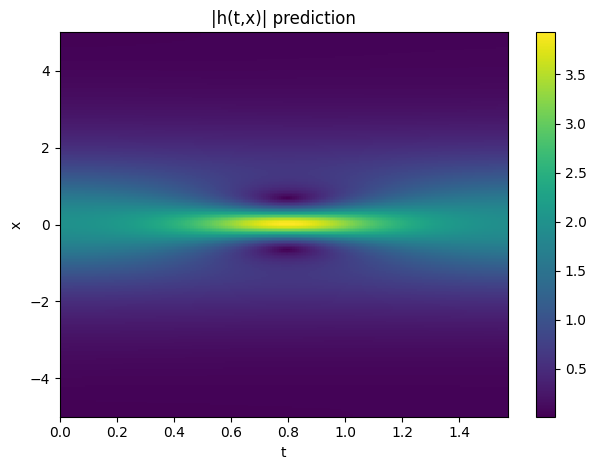

In [20]:
from scipy.interpolate import griddata

def predict(X_star):
    # expects X_star[:,0]=x, X_star[:,1]=t
    x_ = to_tensor(X_star[:, 0:1], device).requires_grad_(True)
    t_ = to_tensor(X_star[:, 1:2], device).requires_grad_(True)
    mlp.eval()
    uv = mlp(x_, t_)
    u = uv[:, 0:1]
    v = uv[:, 1:2]
    # physics residuals (need grads, so not using no_grad for this part)
    # redo with grad:
    x_.requires_grad_(True)
    t_.requires_grad_(True)
    return (
        u.detach().cpu().numpy(),
        v.detach().cpu().numpy(),
    )

u_pred, v_pred = predict(X_star)
h_pred = np.sqrt(u_pred ** 2 + v_pred ** 2)
# (Optional) quick plots similar to TF script
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method="cubic")
V_pred = griddata(X_star, v_pred.flatten(), (X, T), method="cubic")
H_pred = griddata(X_star, h_pred.flatten(), (X, T), method="cubic")
# Example: plot |h(t,x)|
plt.figure()
im = plt.imshow(
    H_pred.T,
    interpolation="nearest",
    extent=[lb[1], ub[1], lb[0], ub[0]],
    origin="lower",
    aspect="auto",
    cmap="viridis",
)
plt.xlabel("t")
plt.ylabel("x")
plt.title("|h(t,x)| prediction")
plt.colorbar(im)
plt.tight_layout()
plt.show()

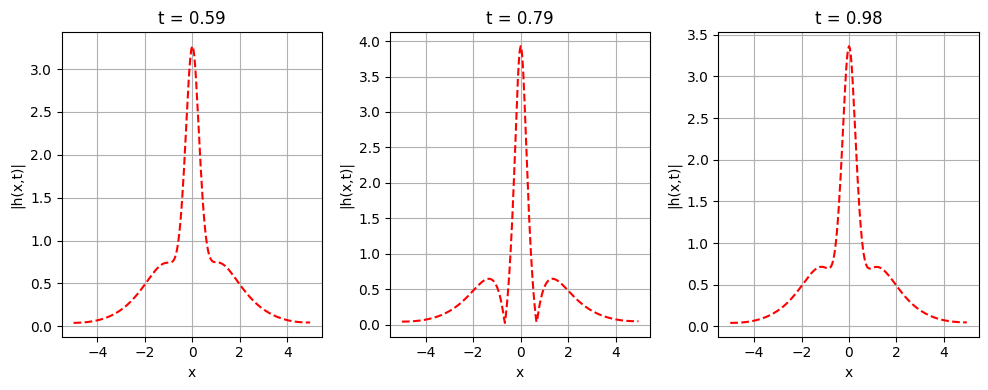

In [ ]:
# choose x grid (same as your training/test grid)
x_vals = x.flatten()[:, None]   # shape (N_x,1)

# times of interest
t_slices = [0.59, 0.79, 0.98]

plt.figure(figsize=(10,4))
for i, t_val in enumerate(t_slices, 1):
    # repeat the t value to match x grid length
    t_vals = np.full_like(x_vals, t_val)

    # build (x,t) input
    X_slice = np.hstack([x_vals, t_vals])

    # predict
    u_pred, v_pred = predict(X_slice)
    h_pred = np.sqrt(u_pred**2 + v_pred**2)

    # plot
    plt.subplot(1,3,i)
    plt.plot(x_vals, h_pred, "r--", label="Prediction")
    plt.xlabel("x")
    plt.ylabel("|h(x,t)|")
    plt.title(f"t = {t_val:.2f}")
    plt.grid(True)

plt.tight_layout()
plt.show()